In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle
from enum import Enum
from copy import deepcopy

DATA_PATH = "D:/ML/RSNA2024"

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
timm.list_models("*maxvit_rmlp*")

['maxvit_rmlp_base_rw_224',
 'maxvit_rmlp_base_rw_384',
 'maxvit_rmlp_nano_rw_256',
 'maxvit_rmlp_pico_rw_256',
 'maxvit_rmlp_small_rw_224',
 'maxvit_rmlp_small_rw_256',
 'maxvit_rmlp_tiny_rw_256']

## Data Processing

In [4]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [5]:
list(df.columns)

['spinal_canal_stenosis_l1_l2',
 'spinal_canal_stenosis_l2_l3',
 'spinal_canal_stenosis_l3_l4',
 'spinal_canal_stenosis_l4_l5',
 'spinal_canal_stenosis_l5_s1',
 'left_neural_foraminal_narrowing_l1_l2',
 'left_neural_foraminal_narrowing_l2_l3',
 'left_neural_foraminal_narrowing_l3_l4',
 'left_neural_foraminal_narrowing_l4_l5',
 'left_neural_foraminal_narrowing_l5_s1',
 'right_neural_foraminal_narrowing_l1_l2',
 'right_neural_foraminal_narrowing_l2_l3',
 'right_neural_foraminal_narrowing_l3_l4',
 'right_neural_foraminal_narrowing_l4_l5',
 'right_neural_foraminal_narrowing_l5_s1',
 'left_subarticular_stenosis_l1_l2',
 'left_subarticular_stenosis_l2_l3',
 'left_subarticular_stenosis_l3_l4',
 'left_subarticular_stenosis_l4_l5',
 'left_subarticular_stenosis_l5_s1',
 'right_subarticular_stenosis_l1_l2',
 'right_subarticular_stenosis_l2_l3',
 'right_subarticular_stenosis_l3_l4',
 'right_subarticular_stenosis_l4_l5',
 'right_subarticular_stenosis_l5_s1']

In [6]:
allConditions = list(df.columns)
allLabels = np.array(df.columns)
allStudyIds = list(df.index)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}
ALL_CLASSES=['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]

class Level(Enum):
    L5_S1 = 'L5/S1'
    L4_L5 = 'L4/L5'
    L3_L4 = 'L3/L4'
    L2_L3 = 'L2/L3'
    L1_L2 = 'L1/L2'


LEVEL = Level.L1_L2

In [7]:
values = ALL_CLASSES
keys = np.arange(0,len(ALL_CLASSES))
IntToClass= dict(zip(keys, values))

classToInt = dict(zip(values, keys))

In [8]:
CONDITIONS = ['spinal_canal_stenosis', 'left_neural_foraminal_narrowing','right_neural_foraminal_narrowing','left_subarticular_stenosis', 'right_subarticular_stenosis']
print(f"Possible conditions per level: {CONDITIONS}")

dfMapped = df.replace(labelMapping)

def getLabelVectorLevels(studyId, level:Level):
    condIdxs = [level.value.replace("/","_").lower() in el for el in np.array(allConditions)]
    conditionsPerLevel = [cond +  "_" +level.value.replace("/","_").lower() for cond in CONDITIONS]
    try:
        labelVec = dfMapped.loc[studyId][conditionsPerLevel]
    except KeyError:
        labelVec = np.zeros_like(conditionsPerLevel)

    return np.array(labelVec)

print(getLabelVectorLevels(4646740, Level.L2_L3))
# assert (getLabelVectorLevels(4646740) == np.array([0,1,0,0,0])).all()

Possible conditions per level: ['spinal_canal_stenosis', 'left_neural_foraminal_narrowing', 'right_neural_foraminal_narrowing', 'left_subarticular_stenosis', 'right_subarticular_stenosis']
[0 0 0 0 1]


C:\Users\manue\AppData\Local\Temp\ipykernel_12452\2293710753.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfMapped = df.replace(labelMapping)


In [9]:
if os.path.exists(os.path.join(DATA_PATH,"./rawData.pkl")):
    with open(os.path.join(DATA_PATH,"./rawData.pkl"), "rb") as f:
        allData = pickle.load(f)

In [10]:
from DicomDataset import *

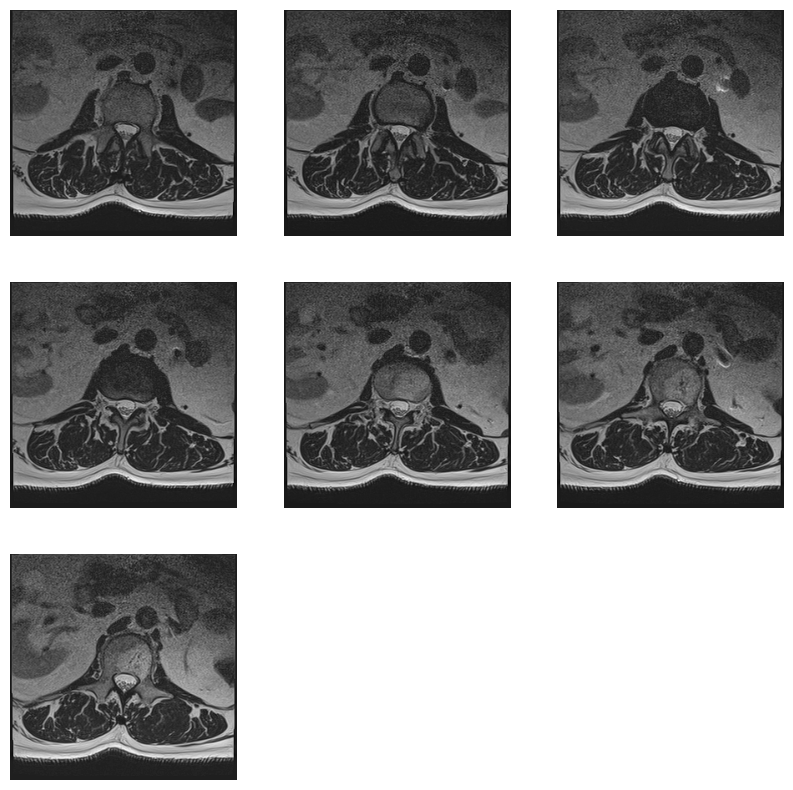

In [11]:
IMG_SIZE = (512, 512)


plt.figure(figsize=(10,10))
testStudId = np.random.choice(allStudyIds)

for i,slice in enumerate(allData[testStudId]["axSlices"][LEVEL.value][0]):
    if i==9:
        break
    plt.subplot(3,3, i+1)
    _ = plt.imshow(slice.data, cmap="gray")
    _ = plt.axis("off")



In [12]:
testStudId

2255930443

## Dataset

In [13]:
# TODO K Fold CV ?

# from sklearn.model_selection import KFold
# X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]])
# y = np.array([1, 2, 3, 4])
# kf = KFold(n_splits=2)

# print(kf)

# for i, (train_index, test_index) in enumerate(kf.split(X)):
#     print(f"Fold {i}:")
#     print(f"  Train: index={train_index}")
#     print(f"  Test:  index={test_index}")

#Fold 0:
#   Train: index=[2 3]
#   Test:  index=[0 1]
# Fold 1:
#   Train: index=[0 1]
#   Test:  index=[2 3]

In [14]:
import random

TRAIN_TEST_SPLIT = 0.7

print(allStudyIds)

np.random.seed(5880)
random.seed(5880)

np.random.shuffle(allStudyIds)
print(allStudyIds)

split = int(len(allStudyIds)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
print("# Validation samples:",len(allStudyIds)-split)

trainStudyIds = allStudyIds[0:split]
valStudyIds = allStudyIds[split:]

assert np.intersect1d(trainStudyIds, valStudyIds).shape[0] == 0

[4003253, 4646740, 7143189, 8785691, 10728036, 11340341, 11943292, 13317052, 22191399, 26342422, 29931867, 33736057, 38281420, 40745534, 41477684, 44060036, 46494080, 52397721, 52695609, 53418228, 58813022, 59576878, 60612428, 63725508, 64092030, 69086098, 70878995, 71973234, 73783367, 74294498, 74782131, 75336136, 76438935, 82066307, 85480902, 86250890, 87937369, 88465004, 89637298, 90711686, 92407737, 92565488, 96439573, 97086905, 97634230, 100206310, 105895264, 106310815, 107698245, 107935613, 108348787, 109454808, 109677683, 110271740, 111701877, 112166434, 113121178, 113758629, 114899184, 115990621, 117720278, 123154253, 128125626, 135073898, 140799588, 142991438, 144244752, 145324113, 150368852, 153831832, 155064828, 158640056, 159099003, 159721286, 165018059, 166255118, 168470924, 168833126, 169651375, 176605889, 177339056, 178041181, 178651310, 180341550, 181779472, 182843007, 183230492, 185510290, 189160688, 189207389, 189360935, 191717032, 198104941, 200354973, 200852737, 206

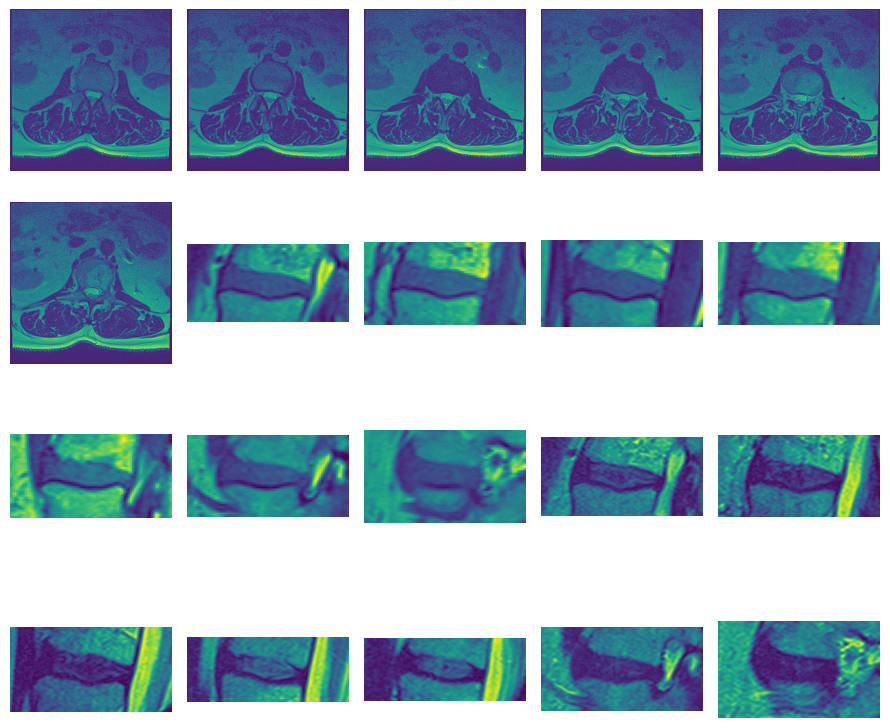

In [15]:
def plotAllData(instance, figsize=(9,10)):
    numIm = len(instance["axSlices"][LEVEL.value][0]) + len(instance["sagittalPatches"][LEVEL.value])
    imCount = int(np.ceil(np.sqrt(numIm))) 
    plt.figure(figsize=figsize)
    i=0
    for i, im in enumerate(instance["axSlices"][LEVEL.value][0]):
        plt.subplot(imCount,imCount,i+1)
        plt.imshow(im.data)
        plt.axis("off")
        plt.tight_layout()
    for j,im in enumerate(instance["sagittalPatches"][LEVEL.value]):
        plt.subplot(imCount,imCount,i+j+1)
        plt.imshow(im)
        plt.axis("off")
        plt.tight_layout()

plotAllData(allData[testStudId])

In [16]:
def plotAll(imArr, figsize=(9,10)):
    numIm = imArr.shape[0]
    imCount = int(np.ceil(np.sqrt(numIm))) 
    plt.figure(figsize=figsize)
    for i in range(imCount**2):
        if i<imArr.shape[0]:
            plt.subplot(imCount,imCount,i+1)
            plt.imshow(imArr[i,:,:])
        plt.axis("off")
        plt.tight_layout()

In [17]:
from threading import Thread
from concurrent.futures import ThreadPoolExecutor

numWorkers=16

import albumentations as A

augProb = 0.1

centerCropFactor=0.7
upScaleFactor = 1/centerCropFactor
upscaledImgSize = [int(IMG_SIZE[0]*upScaleFactor), int(IMG_SIZE[1]*upScaleFactor)]

transforms = A.Compose([
    A.Resize(upscaledImgSize[0], upscaledImgSize[1]),
    A.Crop(upscaledImgSize[0]//2, int(upscaledImgSize[1]*0.1), upscaledImgSize[0], int(upscaledImgSize[1]*0.8)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=augProb),
    A.OneOf([
        A.MotionBlur(blur_limit=7),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=7),
        A.GaussNoise(var_limit=(0.003, 0.02)),
    ], p=augProb),

    A.OneOf([
        A.OpticalDistortion(distort_limit=0.2),
        A.GridDistortion(num_steps=5, distort_limit=0.2),
        A.ElasticTransform(alpha=3, approximate=True, same_dxdy=True),
    ], p=augProb),

    A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.15, rotate_limit=15, border_mode=0, p=augProb),
    A.CoarseDropout(max_holes=10, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, p=augProb),  
    A.Normalize(max_pixel_value=1.0)
])

transformsWithCenterCrop = A.Compose([
    A.Resize(int(IMG_SIZE[0]*upScaleFactor), int(IMG_SIZE[1]*upScaleFactor)),
    A.CenterCrop(int(IMG_SIZE[0]*centerCropFactor), int(IMG_SIZE[1]*centerCropFactor)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=augProb),
    A.OneOf([
        A.MotionBlur(blur_limit=7),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=7),
        A.GaussNoise(var_limit=(0.003, 0.02)),
    ], p=augProb),

    A.OneOf([
        A.OpticalDistortion(distort_limit=0.2),
        A.GridDistortion(num_steps=5, distort_limit=0.2),
        A.ElasticTransform(alpha=3, approximate=True, same_dxdy=True),
    ], p=augProb),

    A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.15, rotate_limit=15, border_mode=0, p=augProb),
    A.CoarseDropout(max_holes=10, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, p=augProb),  
    A.Normalize(max_pixel_value=1.0)
])

transformsVal = A.Compose([
    A.Resize(upscaledImgSize[0], upscaledImgSize[1]),
    A.Crop(upscaledImgSize[0]//2, int(upscaledImgSize[1]*0.1), upscaledImgSize[0], int(upscaledImgSize[1]*0.8)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])

transformsValWithCenterCrop = A.Compose([
    A.Resize(int(IMG_SIZE[0]*1/centerCropFactor), int(IMG_SIZE[1]*1/centerCropFactor)),
    A.CenterCrop(int(IMG_SIZE[0]*centerCropFactor), int(IMG_SIZE[1]*centerCropFactor)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])


numSagSlices=20
numAxSlices=10
DEPTH = numSagSlices+numAxSlices

def transf(imArray, imArrayIdx, centerCrop=False, validate=False):
    imArray[imArrayIdx] = imArray[imArrayIdx]/255.0
    if validate and centerCrop:
        imArray[imArrayIdx] = transformsValWithCenterCrop(image=imArray[imArrayIdx])["image"]
    elif validate:
        imArray[imArrayIdx] = transformsVal(image=imArray[imArrayIdx])["image"]
    elif centerCrop:
        imArray[imArrayIdx] = transformsWithCenterCrop(image=imArray[imArrayIdx])["image"]
    else:
        imArray[imArrayIdx] = transforms(image=imArray[imArrayIdx])["image"]




def transformAsyncPool(pool, imList, centerCrop=False, validate=False):
    results=[]
    for idx, im in enumerate(imList):
        results.append(pool.submit(transf, imList, idx, centerCrop, validate))
    for r in results:
        r.result()



def generator():
    with ThreadPoolExecutor() as pool:
        for trainStudyId in trainStudyIds:
            for level in list(Level):
                instance = allData[trainStudyId]
                axSlices = []
                for axs in instance["axSlices"][level.value]:
                    for sl in axs:
                        axSlices.append(sl)
                sagSlices=[el.astype(np.float32) for el in instance["sagittalPatches"][level.value]]
                imListAxial = [im.data.astype(np.float32) for im in axSlices]
                transformAsyncPool(pool, sagSlices)
                transformAsyncPool(pool, imListAxial, True)
                imArray = np.zeros((numSagSlices+numAxSlices, *IMG_SIZE))
                for iSag in range(numSagSlices):
                    if iSag<len(sagSlices):
                        imArray[iSag, :, :] = sagSlices[iSag]
                for iAx in range(numAxSlices):
                    if iAx<len(imListAxial):
                        imArray[numSagSlices+iAx, :, :] = imListAxial[iAx]
                im = torch.Tensor(imArray)
                label = getLabelVectorLevels(trainStudyId, level)
                yield im, np.array(label).astype(np.int64), level.value



def generatorVal():
    with ThreadPoolExecutor(numWorkers) as valPool:
        for valStudyId in valStudyIds:
            for level in list(Level):
                instanceVal = allData[valStudyId]
                axSlicesVal = []
                for axs in instanceVal["axSlices"][level.value]:
                    for sl in axs:
                        axSlicesVal.append(sl)
                sagSlicesVal=[el.astype(np.float32) for el in instanceVal["sagittalPatches"][level.value]]
                imListAxialVal = [im.data.astype(np.float32) for im in axSlicesVal]
                transformAsyncPool(valPool, sagSlicesVal, False, True)
                transformAsyncPool(valPool, imListAxialVal, True,  True)
                imArrayVal = np.zeros((numSagSlices+numAxSlices, *IMG_SIZE))
                for iSag in range(numSagSlices):
                    if iSag<len(sagSlicesVal):
                        imArrayVal[iSag, :, :] = sagSlicesVal[iSag]
                for iAx in range(numAxSlices):
                    if iAx<len(imListAxialVal):
                        imArrayVal[numSagSlices+iAx, :, :] = imListAxialVal[iAx]
                imVal = torch.Tensor(imArrayVal)
                labelVal = getLabelVectorLevels(valStudyId, level)
                yield imVal, np.array(labelVal).astype(np.int64), level.value

g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.17 (you have 1.4.14). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\pydantic\main.py:193: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  self.__pydantic_validator__.validate_python(data, self_instance=self)


tensor(-2.1179) tensor(2.2489)
torch.Size([30, 512, 512])
['right_neural_foraminal_narrowing' 'left_subarticular_stenosis'
 'right_subarticular_stenosis']
[0 0 1 1 2]
L4/L5


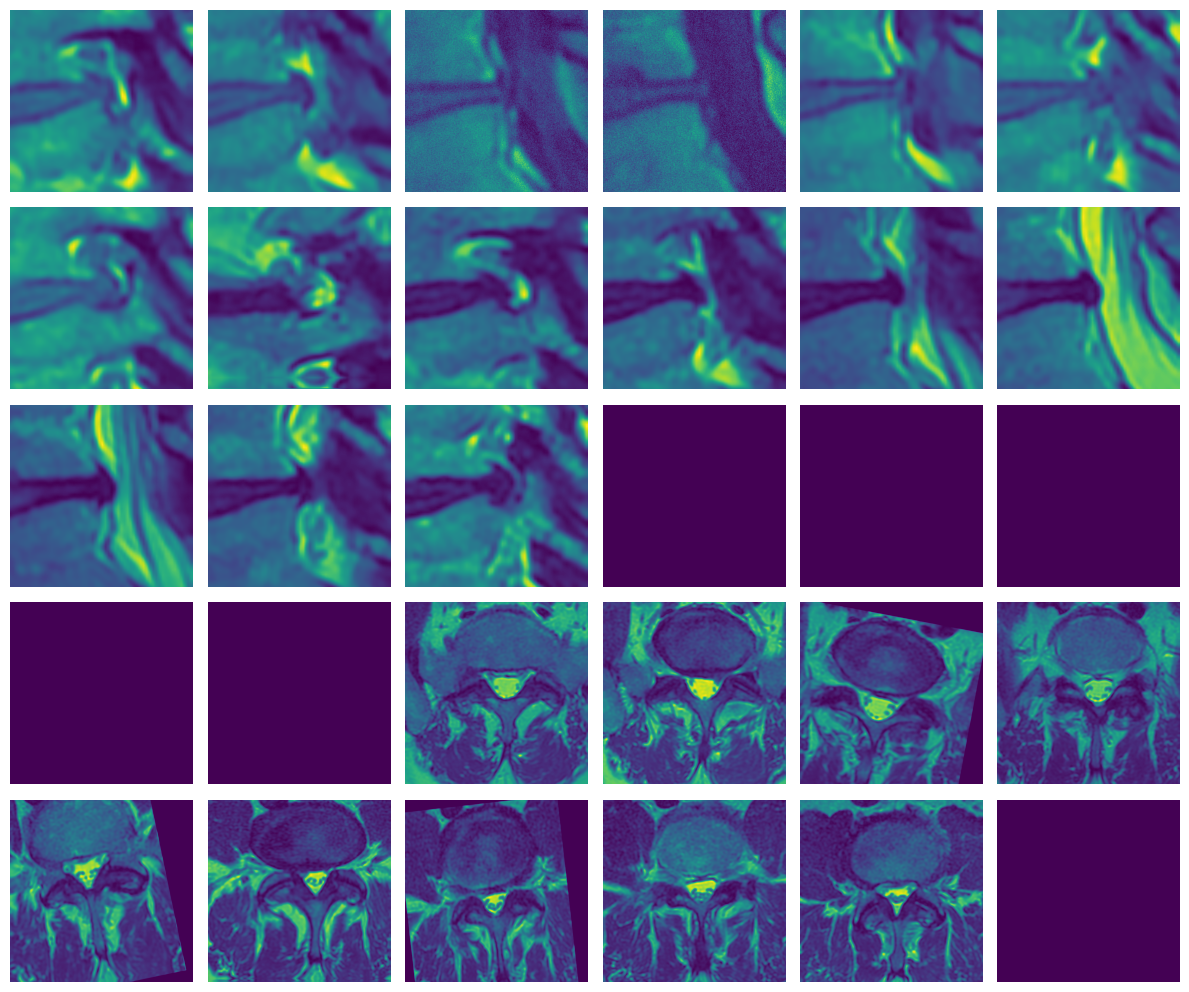

In [18]:
testInstance = next(g)
# testInstance = next(gVal)

plotAll(testInstance[0].numpy(), (12,12))

print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(np.array(CONDITIONS)[testInstance[1]>0])
print(testInstance[1])
print(testInstance[2])

In [19]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    

dataset = IterDataset(generator, len(trainStudyIds)*len(list(Level)))
datasetVal = IterDataset(generatorVal, len(valStudyIds)*len(list(Level)))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False )
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
for XData, targets, lev in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([32, 30, 512, 512]) torch.float32
Max and Min:  tensor(2.2489) tensor(-2.1179)
Shape of target: torch.Size([32, 5]) torch.int64


tensor([0, 0, 0, 0, 0])


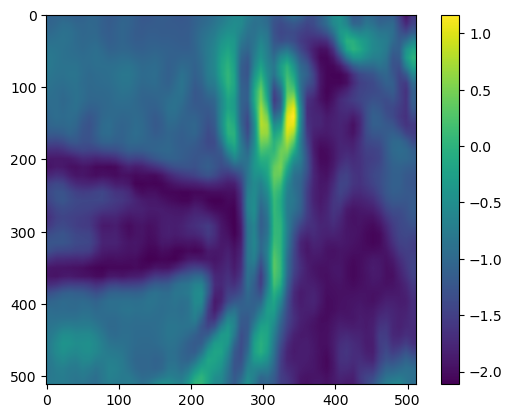

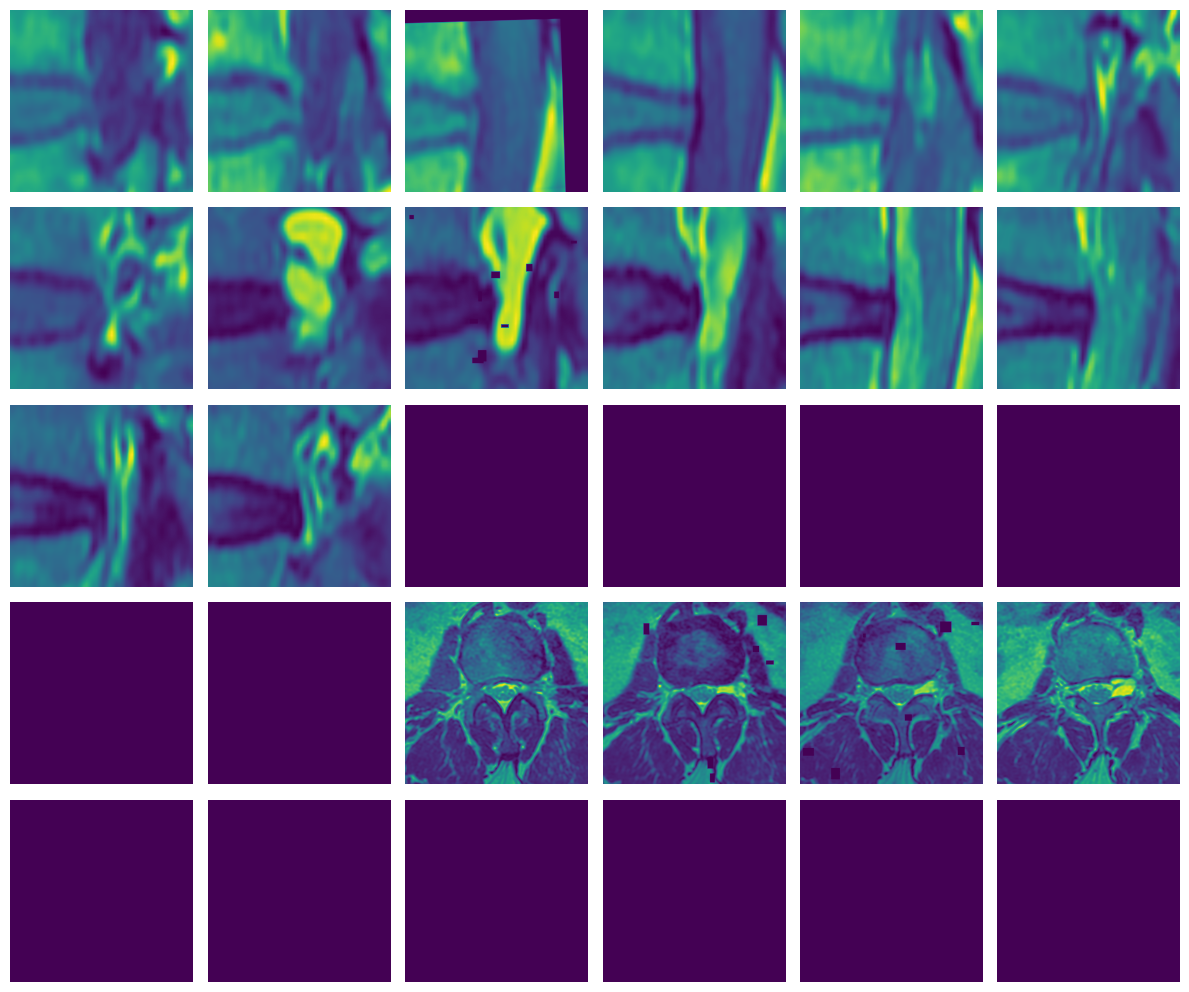

In [21]:
idx=4
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(XData[idx,12,:,:])
plt.colorbar()
# _=plt.axis("off")
plotAll(XData[idx], (12,12))

In [22]:
del XData, targets, testInstance, testInstanceVal

## Model

In [23]:
from utils import FocalLoss

# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
focalloss = FocalLoss()
focalloss(predsTest, targetsTest)

tensor([[[-1.5287,  0.1780, -0.4760,  1.2375, -0.6192, -1.7205, -0.7402,
           1.3431],
         [ 0.8126, -1.5134,  0.0835,  0.8533,  1.6209,  2.6204, -0.6781,
          -2.3343],
         [-0.0832, -0.0089, -1.0490,  0.0073, -1.1068,  0.3205,  1.3994,
           0.5446]]], dtype=torch.float64)


tensor(1.3592, dtype=torch.float64)

In [24]:
import torchinfo


use_amp = True


class Classifier(torch.nn.Module):
    def __init__(self, backbone):
        super(Classifier, self).__init__()
        self.basemodel = timm.create_model(backbone, pretrained=True, num_classes=len(CONDITIONS)*len(labelMapping), in_chans=DEPTH)
        self.name=f"DepthClassifier_{backbone}"

    def forward(self, x):
        x = self.basemodel(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(CONDITIONS)))
        return x


# model = Classifier("caformer_s36")
model = Classifier("edgenext_base")
# model = Classifier("densenet169")
# model = Classifier("maxvit_rmlp_tiny_rw_256")
# model = Classifier("resnet50d")

# from torchview import draw_graph

# model_graph = draw_graph(model, input_size=(BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)


with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
    print(torchinfo.summary(model, input_size=[BATCH_SIZE,DEPTH,IMG_SIZE[0],IMG_SIZE[1]], depth=3))

Layer (type:depth-idx)                                            Output Shape              Param #
Classifier                                                        [32, 3, 5]                --
├─EdgeNeXt: 1-1                                                   [32, 15]                  --
│    └─Sequential: 2-1                                            [32, 80, 128, 128]        --
│    │    └─Conv2d: 3-1                                           [32, 80, 128, 128]        38,480
│    │    └─LayerNorm2d: 3-2                                      [32, 80, 128, 128]        160
│    └─Sequential: 2-2                                            [32, 584, 16, 16]         --
│    │    └─EdgeNeXtStage: 3-3                                    [32, 80, 128, 128]        157,920
│    │    └─EdgeNeXtStage: 3-4                                    [32, 160, 64, 64]         792,808
│    │    └─EdgeNeXtStage: 3-5                                    [32, 288, 32, 32]         6,628,552
│    │    └─EdgeNeXtSta

In [25]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

In [26]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, BinaryAccuracy, BinaryF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=4
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 2


scaler = torch.amp.GradScaler(enabled=use_amp)

log_dir = "./logsSeparateLevel/" + model.name+"_"+str(IMG_SIZE[0]) + "/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
weights = torch.tensor([1.0, 2.0, 4.0]).to(device)
# loss = FocalLoss(weights=weights)
loss = torch.nn.CrossEntropyLoss(weight=weights)
# loss = torch.nn.BCEWithLogitsLoss(weight=weights)
# lossVal = FocalLoss(weights=weights)
weightsVal = torch.tensor([1.0, 2.0, 4.0]).to(device)
lossVal = torch.nn.CrossEntropyLoss(weight=weightsVal)
# lossVal = torch.nn.BCEWithLogitsLoss(weight=weights)

f1Metric = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetric = MulticlassAccuracy(num_classes=len(labelMapping)).to(device)
f1MetricVal = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetricVal = MulticlassAccuracy(num_classes=len(labelMapping), average=None).to(device)

# f1Metric = BinaryF1Score().to(device)
# accMetric = BinaryAccuracy().to(device)
# f1MetricVal = BinaryF1Score().to(device)
# accMetricVal = BinaryAccuracy().to(device)


def train(dataloaderTrain, model, lossFn, optimizer, epoch):
    size = len(dataloaderTrain.dataset)
    model.train()
    for batch, (X, y, lev) in enumerate(dataloaderTrain):
        X, y = X.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloaderVal, model, loss_fn, epoch):
    num_batches = len(dataloaderVal)
    model.eval()
    valLosses = []
    with torch.no_grad():
        for XVal, yVal, levVal in dataloaderVal:
            XVal, yVal = XVal.to(device), yVal.to(device)
            predVal = model(XVal)
            # pred = torch.reshape(pred, (pred.shape[0], len(labelMapping), len(allLabels)))
            # valLoss += loss_fn(predVal, yVal).item()
            valLosses.append(loss_fn(predVal, yVal).item())
            accMetricVal.update(predVal, yVal)
            f1MetricVal.update(predVal, yVal)

    valLoss = np.mean(valLosses)
    fig_, ax_ = accMetricVal.plot()
    fig_.savefig(f"./valPlots/acc_{t}.png")
    plt.close()
    
    print(f"Validation: Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {torch.mean(accMetricVal.compute()):.4f} \n")
    summary_writer.add_scalar("Val Loss", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()
    return valLoss

bestPerformance=99
bestEpoch=0

for t in np.arange(startEpoch, startEpoch + epochs, 1):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, loss, optimizer, t)
    valLoss=validate(valLoader, model, lossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if valLoss < bestPerformance:
        bestPerformance = valLoss
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = deepcopy(model.state_dict())
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}, {bestPerformance=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

Epoch 1
-------------------------------
loss: 1.106363, Acc: 0.2917, F1: 0.2800  [   32/ 6910]
loss: 0.972426, Acc: 0.3774, F1: 0.3590  [  160/ 6910]
loss: 0.948792, Acc: 0.3504, F1: 0.3500  [  288/ 6910]
loss: 1.064191, Acc: 0.3435, F1: 0.3400  [  416/ 6910]
loss: 1.078843, Acc: 0.3396, F1: 0.3312  [  544/ 6910]
loss: 0.987100, Acc: 0.3412, F1: 0.3312  [  672/ 6910]
loss: 0.994571, Acc: 0.3407, F1: 0.3281  [  800/ 6910]
loss: 0.883352, Acc: 0.3397, F1: 0.3246  [  928/ 6910]
loss: 1.060580, Acc: 0.3387, F1: 0.3210  [ 1056/ 6910]
loss: 0.936954, Acc: 0.3401, F1: 0.3218  [ 1184/ 6910]
loss: 0.906035, Acc: 0.3422, F1: 0.3230  [ 1312/ 6910]
loss: 0.962090, Acc: 0.3427, F1: 0.3230  [ 1440/ 6910]
loss: 0.872589, Acc: 0.3451, F1: 0.3263  [ 1568/ 6910]
loss: 0.695737, Acc: 0.3456, F1: 0.3274  [ 1696/ 6910]
loss: 0.755849, Acc: 0.3464, F1: 0.3288  [ 1824/ 6910]
loss: 0.887846, Acc: 0.3482, F1: 0.3340  [ 1952/ 6910]
loss: 0.773266, Acc: 0.3492, F1: 0.3365  [ 2080/ 6910]
loss: 1.211393, Acc: 0.34

In [27]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join(DATA_PATH, f"{model.name}_{IMG_SIZE[0]}_F1_{bestF1:.3f}_CE_{bestPerformance:.3f}_epoch_{bestEpoch}.pt"))

print(f"Saved {model.name}_{IMG_SIZE[0]}_F1_{bestF1:.3f}_CE_{bestPerformance:.3f}_epoch_{bestEpoch}.pt")

<All keys matched successfully>
Saved DepthClassifier_edgenext_base_512_F1_0.572_CE_0.645_epoch_5.pt
